# 下一课：Cliff Walking 悬崖行走

这一课我们进入强化学习里非常经典的环境：`Cliff Walking`。

它特别适合用来理解：
- 为什么 `Q-learning` 往往更乐观
- 为什么 `SARSA` 往往更保守
- 在“有风险”的环境里，算法风格为什么会影响最终策略


## 1. 环境长什么样

我们用一个 `4 x 12` 的网格世界：

- 左下角是起点 `S`
- 右下角是终点 `G`
- 底边中间那一整排是悬崖 `C`

示意图大概是这样：

`.` `.` `.` `.` `.` `.` `.` `.` `.` `.` `.` `.`

`.` `.` `.` `.` `.` `.` `.` `.` `.` `.` `.` `.`

`.` `.` `.` `.` `.` `.` `.` `.` `.` `.` `.` `.`

`S` `C` `C` `C` `C` `C` `C` `C` `C` `C` `C` `G`

规则是：
- 每走一步奖励 `-1`
- 掉下悬崖奖励 `-100`，并回到起点
- 到达终点 episode 结束

所以智能体需要在“走更短的路”和“远离危险”之间做权衡。


In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)
random.seed(42)
np.random.seed(42)


In [9]:
class CliffWalkingEnv:
    def __init__(self, rows=4, cols=12):
        self.rows = rows
        self.cols = cols
        self.n_states = rows * cols
        self.n_actions = 4  # 0=up, 1=right, 2=down, 3=left
        self.start = (rows - 1, 0)
        self.goal = (rows - 1, cols - 1)
        self.cliff = {(rows - 1, c) for c in range(1, cols - 1)}
        self.reset()

    def to_state(self, pos):
        return pos[0] * self.cols + pos[1]

    def reset(self):
        self.agent = self.start
        return self.to_state(self.agent)

    def step(self, action):
        r, c = self.agent

        if action == 0:
            r = max(0, r - 1)
        elif action == 1:
            c = min(self.cols - 1, c + 1)
        elif action == 2:
            r = min(self.rows - 1, r + 1)
        else:
            c = max(0, c - 1)

        next_pos = (r, c)

        if next_pos in self.cliff:
            reward = -100
            self.agent = self.start
            done = False
            return self.to_state(self.agent), reward, done

        self.agent = next_pos
        done = self.agent == self.goal
        reward = -1
        return self.to_state(self.agent), reward, done

    def render_policy(self, policy):
        action_map = {0: 'U', 1: 'R', 2: 'D', 3: 'L'}
        grid = []
        for r in range(self.rows):
            row = []
            for c in range(self.cols):
                pos = (r, c)
                if pos == self.start:
                    row.append('S')
                elif pos == self.goal:
                    row.append('G')
                elif pos in self.cliff:
                    row.append('C')
                else:
                    state = self.to_state(pos)
                    row.append(action_map[int(policy[state])])
            grid.append(row)
        return grid


## 2. 动作选择函数

我们继续使用 `epsilon-greedy`：
- 有一定概率随机探索
- 其余时候选择当前最优动作

并且如果多个动作价值一样，就随机从并列最优动作里挑一个。


In [10]:
def choose_action(state, q_table, epsilon):
    if random.random() < epsilon:
        return random.randint(0, q_table.shape[1] - 1)

    best_actions = np.flatnonzero(q_table[state] == np.max(q_table[state]))
    return int(random.choice(best_actions))


## 3. 训练 Q-learning 和 SARSA

这里的训练代码和上一课非常像，但在这个环境里，两个算法的差异会更明显。


In [12]:
def train_q_learning(env, episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1, max_steps=1000):
    q_table = np.zeros((env.n_states, env.n_actions))
    episode_rewards = []

    for _ in range(episodes):
        state = env.reset()
        total_reward = 0

        for _step in range(max_steps):
            action = choose_action(state, q_table, epsilon)
            next_state, reward, done = env.step(action)

            old_value = q_table[state, action]
            next_best = 0 if done else np.max(q_table[next_state])
            target = reward + gamma * next_best
            q_table[state, action] = old_value + alpha * (target - old_value)

            state = next_state
            total_reward += reward

            if done:
                break

        episode_rewards.append(total_reward)

    return q_table, episode_rewards


def train_sarsa(env, episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1, max_steps=1000):
    q_table = np.zeros((env.n_states, env.n_actions))
    episode_rewards = []

    for _ in range(episodes):
        state = env.reset()
        action = choose_action(state, q_table, epsilon)
        total_reward = 0

        for _step in range(max_steps):
            next_state, reward, done = env.step(action)
            old_value = q_table[state, action]
            total_reward += reward

            if done:
                target = reward
                q_table[state, action] = old_value + alpha * (target - old_value)
                break

            next_action = choose_action(next_state, q_table, epsilon)
            target = reward + gamma * q_table[next_state, next_action]
            q_table[state, action] = old_value + alpha * (target - old_value)

            state = next_state
            action = next_action

        episode_rewards.append(total_reward)

    return q_table, episode_rewards


In [13]:
env_q = CliffWalkingEnv()
env_s = CliffWalkingEnv()

q_q_learning, rewards_q = train_q_learning(env_q)
q_sarsa, rewards_s = train_sarsa(env_s)

print('训练完成。')
print('Q-learning 最后 10 轮平均 reward:', round(float(np.mean(rewards_q[-10:])), 2))
print('SARSA 最后 10 轮平均 reward:', round(float(np.mean(rewards_s[-10:])), 2))


训练完成。
Q-learning 最后 10 轮平均 reward: -89.6
SARSA 最后 10 轮平均 reward: -21.4


In [14]:
policy_q = np.argmax(q_q_learning, axis=1)
policy_s = np.argmax(q_sarsa, axis=1)

grid_q = env_q.render_policy(policy_q)
grid_s = env_s.render_policy(policy_s)

print('Q-learning 学到的策略：')
for row in grid_q:
    print(' '.join(row))

print()
print('SARSA 学到的策略：')
for row in grid_s:
    print(' '.join(row))


Q-learning 学到的策略：
R R D R R R R R L D R D
R D D D R R R R R D R D
R R R R R R R R R R R D
S C C C C C C C C C C G

SARSA 学到的策略：
D R R R R R R R R R R D
R U U L R U U U R U R D
U U U U R R U U L L R D
S C C C C C C C C C C G


C:\Users\80740\AppData\Local\Temp\ipykernel_25612\4227775395.py:12: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_25612\4227775395.py:12: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_25612\4227775395.py:12: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_25612\4227775395.py:12: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\80740\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\80740\.conda\envs\rl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

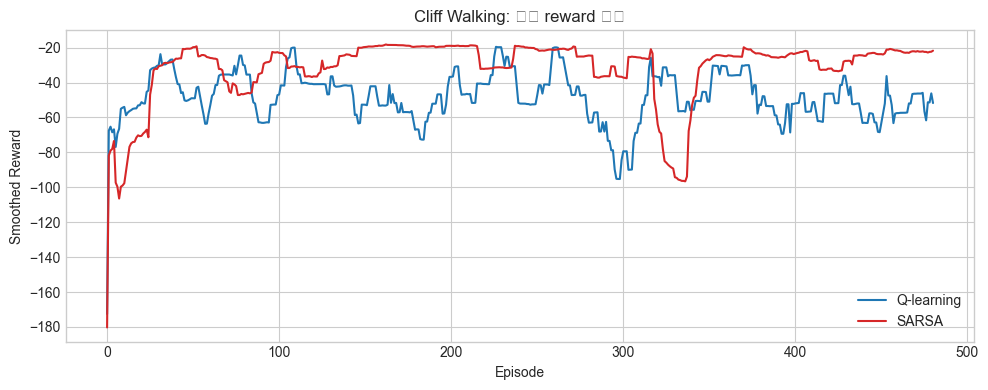

In [15]:
window = 20
smoothed_q = np.convolve(rewards_q, np.ones(window) / window, mode='valid')
smoothed_s = np.convolve(rewards_s, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smoothed_q, label='Q-learning', color='#1f77b4')
plt.plot(smoothed_s, label='SARSA', color='#d62728')
plt.title('Cliff Walking: 平均 reward 对比')
plt.xlabel('Episode')
plt.ylabel('Smoothed Reward')
plt.legend()
plt.tight_layout()
plt.show()


## 4. 你通常会看到什么现象

这个实验最经典的现象是：

- `Q-learning` 往往学出一条贴着悬崖边走的最短路径
- `SARSA` 往往学出一条更安全、离悬崖更远的路径

为什么？

- `Q-learning` 更新时默认下一步会选最优动作，所以它对未来更乐观
- `SARSA` 更新时会把当前策略里的探索风险也算进去

在靠近悬崖时，如果你还有一定概率随机探索，那么 `SARSA` 会意识到：
"我虽然理论上可以贴边走，但只要手抖一下就会掉下去。"

所以它更容易主动绕远一点，换取更稳定的长期回报。


## 5. 这一课记住什么

1. `Q-learning` 更像是在学理想情况下的最优值。
2. `SARSA` 更像是在学当前行为策略下的真实风险。
3. 在危险环境里，on-policy 和 off-policy 的差别会非常明显。

最自然的下一课可以接：
- `FrozenLake` 入门
- `GridWorld` 带障碍物和惩罚
- 从表格法过渡到 `Deep Q-Network (DQN)`
